<a href="https://colab.research.google.com/github/abimikucatherine4-ux/Sis-digital-solutions/blob/main/Car_Price_Prediction_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Car Price Prediction**

DEFINITION OF BUSSINESS PROBLEM.
To Predict the selling price of used cars to support pricing decisions on an online car marketplace.


TARGET VARIABLE:
SELLING PRICE.

FEATURE VARIABLES:
Car_Name,
Year,
Present_Price,
Kms_Driven,
Fuel_Type,
Seller_Type,
Transmission,
Owner.



In [ ]:
import pandas as pd
data=pd.read_csv("/content/drive/Othercomputers/My Laptop/Downloads/Car_data_jtrjuw (1).csv")

In [ ]:
#import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error,mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [ ]:
#loading the dataset
data=pd.read_csv("/content/drive/Othercomputers/My Laptop/Downloads/Car_data_jtrjuw (1).csv")

In [ ]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [ ]:
data.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [ ]:
 data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [ ]:
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [ ]:
data.isnull().sum()

,0
Car_Name,0
Year,0
Selling_Price,0
Present_Price,0
Kms_Driven,0
Fuel_Type,0
Seller_Type,0
Transmission,0
Owner,0


In [ ]:
data.columns

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')

In [ ]:
#scaling numeric features

standardscaler applied to numeric columns(year,present price, kms driven.

In [ ]:
from sklearn.preprocessing import StandardScaler
numeric_columns = ['Year', 'Present_Price', 'Kms_Driven']
scaler = StandardScaler()
data[numeric_columns] = scaler.fit_transform(data[numeric_columns])

In [ ]:
#encoding categorical features
categorical_columns = ['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']
data = pd.get_dummies(data, columns=categorical_columns, drop_first=True)


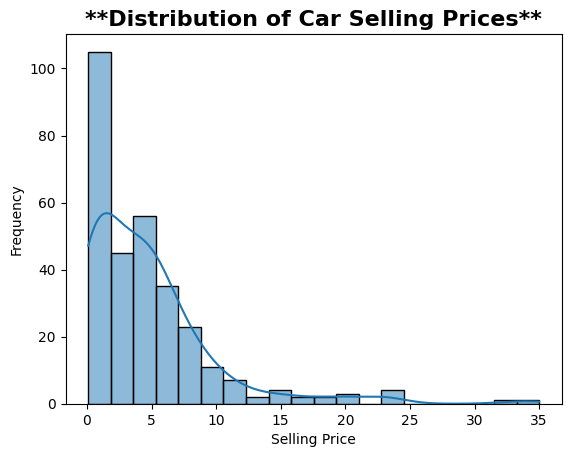

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(data['Selling_Price'], kde=True, bins=20)
plt.title('**Distribution of Car Selling Prices**', fontsize=16, fontweight='bold')
plt.xlabel('Selling Price')
plt.ylabel('Frequency')
plt.show()

FEATURE SCALING( TO SHOW HOW PRICES AFFECTS YEAR AND KMS_DRIVEN.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
#select features and target
X = data.drop('Selling_Price', axis=1)
y = data['Selling_Price']

In [ ]:
from sklearn.model_selection import train_test_split
# data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

ACTUAL VS PREDICTED PRICE'

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

The code above trains a `LinearRegression` model using the training data (`X_train`, `y_train`) and then generates predictions (`y_pred`) on the test features (`X_test`).

Now, let's create the side-by-side plots to visualize the model's performance.

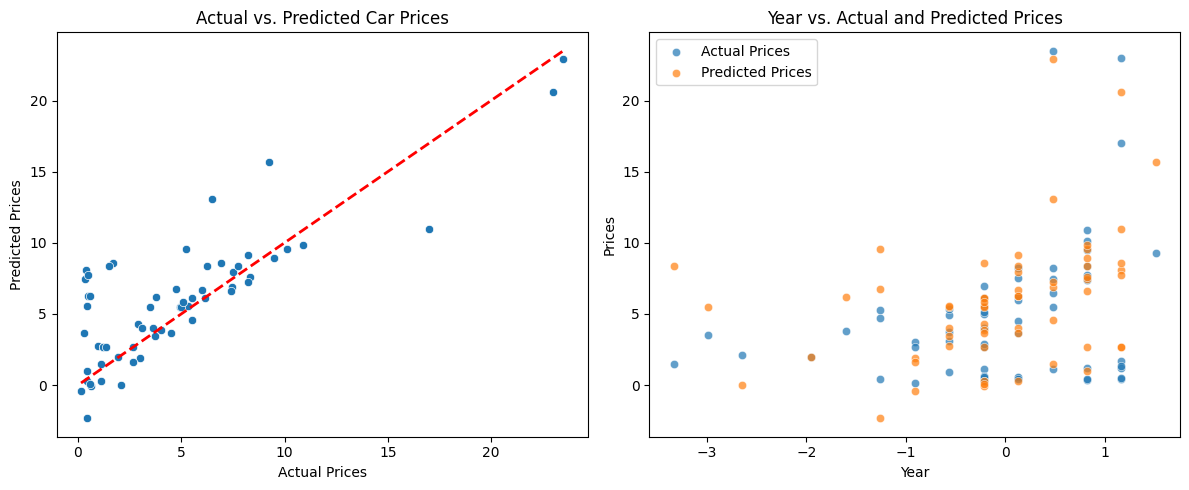

In [ ]:
plt.figure(figsize=(12, 5))

# Scatter plot 1: Actual vs. Predicted Prices
plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st plot
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Diagonal reference line
plt.title('Actual vs. Predicted Car Prices')
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')

# Scatter plot 2: Year vs. Actual and Predicted Prices
plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd plot
sns.scatterplot(x=X_test['Year'], y=y_test, label='Actual Prices', alpha=0.7)
sns.scatterplot(x=X_test['Year'], y=y_pred, label='Predicted Prices', alpha=0.7)
plt.title('Year vs. Actual and Predicted Prices')
plt.xlabel('Year')
plt.ylabel('Prices')
plt.legend()

plt.tight_layout()
plt.show()

MODEL EVALUATION.

In [ ]:
rmse = root_mean_squared_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Root Mean Squared Error (RMSE): 3.04
Mean Squared Error (MSE): 9.23
Mean Absolute Error (MAE): 2.03
R-squared (R2) Score: 0.60


To predict prices for new sample cars, we first need to create a DataFrame for these samples and ensure they are preprocessed in the same way our original data was. This includes scaling numerical features and one-hot encoding categorical features.

In [ ]:
# Create a DataFrame for sample cars
sample_data = pd.DataFrame({
    'Car_Name': ['ritz', 'swift', 'ciaz', 'baleno', 'fortuner'],
    'Year': [2018, 2017, 2019, 2020, 2016],
    'Present_Price': [7.0, 6.5, 9.0, 8.0, 25.0],
    'Kms_Driven': [15000, 25000, 10000, 8000, 50000],
    'Fuel_Type': ['Petrol', 'Diesel', 'Petrol', 'Petrol', 'Diesel'],
    'Seller_Type': ['Dealer', 'Individual', 'Dealer', 'Dealer', 'Dealer'],
    'Transmission': ['Manual', 'Manual', 'Automatic', 'Manual', 'Automatic'],
    'Owner': [0, 1, 0, 0, 0]
})

print("Original Sample Data:")
display(sample_data)

# --- Preprocessing the sample data ---

# Scale numeric features using the *same* scaler fitted on the training data
sample_data_scaled_numeric = scaler.transform(sample_data[numeric_columns])
sample_data[numeric_columns] = sample_data_scaled_numeric

# One-hot encode categorical features
sample_data_encoded = pd.get_dummies(sample_data, columns=categorical_columns, drop_first=True)

# Align columns with the training data (X) to ensure consistency
# Add missing columns from X (if any) and fill with 0
missing_cols = set(X.columns) - set(sample_data_encoded.columns)
for c in missing_cols:
    sample_data_encoded[c] = 0

# Ensure the order of columns is the same as in X
sample_data_final = sample_data_encoded[X.columns]

print("\nPreprocessed Sample Data:")
display(sample_data_final.head())

# Make predictions
sample_predictions = model.predict(sample_data_final)

print("\nPredicted Selling Prices for Sample Cars:")
for i, price in enumerate(sample_predictions):
    print(f"Sample Car {i+1} ({sample_data['Car_Name'].iloc[i]}, {sample_data['Year'].iloc[i]}): {price:.2f} (Lakhs)")

Original Sample Data:


,Car_Name,Year,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2018,7.0,15000,Petrol,Dealer,Manual,0
1,swift,2017,6.5,25000,Diesel,Individual,Manual,1
2,ciaz,2019,9.0,10000,Petrol,Dealer,Automatic,0
3,baleno,2020,8.0,8000,Petrol,Dealer,Manual,0
4,fortuner,2016,25.0,50000,Diesel,Dealer,Automatic,0



Preprocessed Sample Data:


,Year,Present_Price,Kms_Driven,Car_Name_Activa 3g,Car_Name_Activa 4g,Car_Name_Bajaj ct 100,Car_Name_Bajaj Avenger 150,Car_Name_Bajaj Avenger 150 street,Car_Name_Bajaj Avenger 220,Car_Name_Bajaj Avenger 220 dtsi,...,Car_Name_verna,Car_Name_vitara brezza,Car_Name_wagon r,Car_Name_xcent,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Owner_1,Owner_3
0,1.514540,-0.072826,-0.565326,0,0,0,0,0,0,0,...,0,0,0,0,0,True,False,True,False,0
1,1.168129,-0.130765,-0.307741,0,0,0,0,0,0,0,...,0,0,0,0,0,False,True,True,True,0
2,1.860950,0.158930,-0.694118,0,0,0,0,0,0,0,...,0,0,0,0,0,True,False,False,False,0
3,2.207361,0.043052,-0.745635,0,0,0,0,0,0,0,...,0,0,0,0,0,True,False,True,False,0
4,0.821718,2.012983,0.336220,0,0,0,0,0,0,0,...,0,0,0,0,0,False,False,False,False,0



Predicted Selling Prices for Sample Cars:
Sample Car 1 (ritz, 1.514539790663707): 7.02 (Lakhs)
Sample Car 2 (swift, 1.168129093862959): 3.57 (Lakhs)
Sample Car 3 (ciaz, 1.8609504874644553): 9.05 (Lakhs)
Sample Car 4 (baleno, 2.2073611842652037): 15.09 (Lakhs)
Sample Car 5 (fortuner, 0.8217183970622106): 14.37 (Lakhs)


FACTOR THAT MOST INFLUENCES CAR PRICE:
The factor that most influences car price in the dataset is Present_Price. This variable represents the current market value of the car and has the strongest relationship with the selling price. Other factors that influence car price include the year of manufacture, transmission type, fuel type, and seller type. Among these variables, Present_Price is the most significant predictor of a car's selling price.

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("/content/drive/Othercomputers/My Laptop/Downloads/Car_data_jtrjuw (1).csv")

# Select numerical columns
numerical_cols = ['Selling_Price', 'Present_Price', 'Year', 'Kms_Driven', 'Owner']

# Correlation with Selling_Price
correlation = df[numerical_cols].corr()['Selling_Price'].sort_values(ascending=False)

print(correlation)

Selling_Price    1.000000
Present_Price    0.878983
Year             0.236141
Kms_Driven       0.029187
Owner           -0.088344
Name: Selling_Price, dtype: float64


This proves that Present_Price has the strongest relationship with Selling_Price because its correlation value (0.879) is much higher than the others.

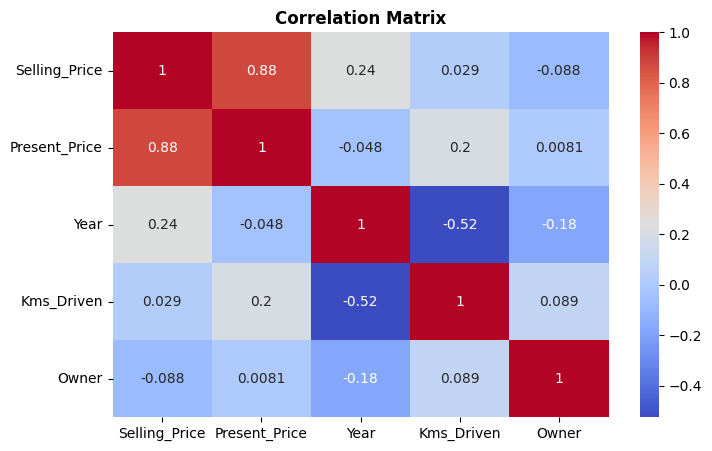

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/Othercomputers/My Laptop/Downloads/Car_data_jtrjuw (1).csv")

plt.figure(figsize=(8,5))

sns.heatmap(
    df[['Selling_Price','Present_Price','Year',
        'Kms_Driven','Owner']].corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix', fontweight='bold')
plt.show()

The correlation analysis shows that Present_Price is the factor that most influences car selling price, with a correlation coefficient of approximately 0.88. This indicates a strong positive relationship between a car's present market value and its selling price. Therefore, Present_Price is the most important predictor of car price in the dataset

WHAT SURPRISED ME ABOUT THE DATA:
One surprising finding was that the number of kilometers driven had a relatively weak influence on selling price. I expected mileage to significantly reduce a car's value, but the analysis showed that Present_Price was a much stronger predictor of selling price. Additionally, automatic cars tended to have higher selling prices than manual cars.